# Uncertainty-Aware Summary

This notebook summarizes the revised historical collapse dataset with uncertainty kept visible throughout. It treats `9` as structured unknown data, not as a numeric score, and is designed for reporting and interpretation rather than prediction.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

plt.style.use("default")
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)

In [2]:
project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent

src_dir = project_root / "src"
if str(src_dir) not in sys.path:
    sys.path.append(str(src_dir))

from config import COLLAPSE_DATASET_PATH
from dataset_utils import get_factor_columns, load_collapse_dataset

factor_categories = {
    "political": [
        "political_fragmentation",
        "elite_conflict",
        "succession_crisis",
        "legitimacy_crisis",
        "administrative_overload",
        "corruption_governance_failure",
    ],
    "social": [
        "social_inequality",
        "social_unrest_rebellion",
        "demographic_pressure",
        "migration_pressure",
        "ethnic_sectarian_fragmentation",
        "urban_decline",
    ],
    "economic": [
        "fiscal_crisis",
        "taxation_extraction_pressure",
        "trade_disruption",
        "inflation_currency_instability",
        "resource_dependency",
        "agricultural_decline",
    ],
    "environmental": [
        "drought_climate_stress",
        "flood_environmental_shock",
        "temperature_anomaly",
        "ecological_degradation",
        "food_insecurity",
    ],
    "military_geopolitical": [
        "external_invasion_pressure",
        "civil_war_internal_conflict",
        "military_overstretch",
        "territorial_loss",
    ],
    "resilience_institutional": [
        "institutional_rigidity",
        "adaptive_capacity",
        "logistics_food_storage_resilience",
        "alliance_network_strength",
        "recovery_capacity",
    ],
}

df = load_collapse_dataset(COLLAPSE_DATASET_PATH)
factor_cols = get_factor_columns()
factor_data = df[factor_cols].apply(pd.to_numeric, errors="coerce")
known_factor_data = factor_data.where(factor_data.isin([0, 1, 2, 3]))

case_category_records = []
for case_name, case_df in df.groupby("case_name", sort=True):
    for category, cols in factor_categories.items():
        category_values = factor_data.loc[case_df.index, cols]
        category_known = known_factor_data.loc[case_df.index, cols]
        total_slots = category_values.shape[0] * category_values.shape[1]
        unknown_count = int(category_values.eq(9).sum().sum())
        known_count = int(category_known.notna().sum().sum())
        case_category_records.append(
            {
                "case_name": case_name,
                "category": category,
                "unknown_prop": unknown_count / total_slots if total_slots else np.nan,
                "known_count": known_count,
                "mean_known_score": category_known.stack().mean(),
            }
        )

case_category_summary = pd.DataFrame(case_category_records)

case_uncertainty = pd.DataFrame(
    {
        "rows": df.groupby("case_name").size(),
        "known_factor_values": known_factor_data.notna().sum(axis=1).groupby(df["case_name"]).sum(),
        "unknown_9_values": factor_data.eq(9).sum(axis=1).groupby(df["case_name"]).sum(),
        "mean_known_factor_score": known_factor_data.mean(axis=1).groupby(df["case_name"]).mean(),
        "avg_collapse_outcome": df.groupby("case_name")["collapse_outcome"].mean(),
        "data_confidence_mode": df.groupby("case_name")["data_confidence"].agg(lambda s: s.mode().iloc[0] if not s.mode().empty else s.iloc[0]),
    }
)
case_uncertainty["total_factor_slots"] = case_uncertainty["rows"] * len(factor_cols)
case_uncertainty["unknown_prop"] = case_uncertainty["unknown_9_values"] / case_uncertainty["total_factor_slots"]
case_uncertainty = case_uncertainty.sort_values(["unknown_prop", "mean_known_factor_score"], ascending=[False, False])
case_uncertainty[["mean_known_factor_score", "avg_collapse_outcome", "unknown_prop"]] = case_uncertainty[["mean_known_factor_score", "avg_collapse_outcome", "unknown_prop"]].round(3)

factor_uncertainty = pd.DataFrame(
    {
        "category": pd.Series({factor: category for category, cols in factor_categories.items() for factor in cols}),
        "known_n": known_factor_data.notna().sum(),
        "unknown_9_n": factor_data.eq(9).sum(),
        "mean_known_score": known_factor_data.mean(),
    }
)
factor_uncertainty["unknown_prop"] = factor_uncertainty["unknown_9_n"] / len(df)
factor_uncertainty = factor_uncertainty.sort_values(["unknown_prop", "mean_known_score"], ascending=[False, False])
factor_uncertainty[["unknown_prop", "mean_known_score"]] = factor_uncertainty[["unknown_prop", "mean_known_score"]].round(3)

case_category_unknown = case_category_summary.pivot(index="case_name", columns="category", values="unknown_prop")
case_category_known_n = case_category_summary.pivot(index="case_name", columns="category", values="known_count")
case_category_mean = case_category_summary.pivot(index="case_name", columns="category", values="mean_known_score")

case_stress = pd.DataFrame(
    {
        "mean_known_factor_score": known_factor_data.mean(axis=1).groupby(df["case_name"]).mean(),
        "known_factor_values": known_factor_data.notna().sum(axis=1).groupby(df["case_name"]).sum(),
        "unknown_prop": factor_data.eq(9).sum(axis=1).groupby(df["case_name"]).mean() / len(factor_cols),
        "avg_collapse_outcome": df.groupby("case_name")["collapse_outcome"].mean(),
    }
)
case_stress = case_stress.sort_values(["mean_known_factor_score", "known_factor_values"], ascending=[False, False]).round(3)

row_evidence_limits = df[["case_id", "case_name", "period_start", "period_end", "phase_label", "collapse_outcome", "data_confidence", "notes"]].copy()
row_evidence_limits["known_factor_count"] = known_factor_data.notna().sum(axis=1)
row_evidence_limits["unknown_9_count"] = factor_data.eq(9).sum(axis=1)
row_evidence_limits["unknown_prop"] = row_evidence_limits["unknown_9_count"] / len(factor_cols)
row_evidence_limits["mean_known_factor_score"] = known_factor_data.mean(axis=1)
row_evidence_limits = row_evidence_limits.sort_values(
    ["known_factor_count", "unknown_prop", "data_confidence", "collapse_outcome"],
    ascending=[True, False, True, False],
)
row_evidence_limits[["unknown_prop", "mean_known_factor_score"]] = row_evidence_limits[["unknown_prop", "mean_known_factor_score"]].round(3)

df.shape

(174, 45)

## Case Uncertainty Table

This table summarizes uncertainty and known-score intensity at the case level.

In [3]:
display(case_uncertainty)

,rows,known_factor_values,unknown_9_values,mean_known_factor_score,avg_collapse_outcome,data_confidence_mode,total_factor_slots,unknown_prop
case_name,,,,,,,,
Bronze Age Collapse States,8,138,118,1.487,1.750,low,256,0.461
Easter Island,20,346,294,0.991,1.100,low,640,0.459
Maya,14,287,161,1.465,1.214,medium,448,0.359
Classic Mesopotamian States,20,425,215,1.566,1.400,low,640,0.336
Inca Empire,7,152,72,1.316,0.857,medium,224,0.321
Sassanian Empire,7,156,68,1.448,1.286,medium,224,0.304
Aztec Empire,5,115,45,1.393,1.000,medium,160,0.281
Western Roman Empire,24,559,209,1.474,1.042,medium,768,0.272
Akkadian Empire,8,187,69,1.590,1.500,low,256,0.270


## Factor Uncertainty Table

This table shows which factors remain most uncertain across the full dataset.

In [4]:
display(factor_uncertainty)

,category,known_n,unknown_9_n,mean_known_score,unknown_prop
temperature_anomaly,environmental,13,161,0.231,0.925
flood_environmental_shock,environmental,16,158,0.688,0.908
inflation_currency_instability,economic,19,155,1.526,0.891
ethnic_sectarian_fragmentation,social,31,143,0.645,0.822
ecological_degradation,environmental,36,138,1.306,0.793
demographic_pressure,social,41,133,1.098,0.764
drought_climate_stress,environmental,42,132,1.286,0.759
corruption_governance_failure,political,58,116,1.983,0.667
migration_pressure,social,100,74,1.240,0.425
social_inequality,social,109,65,1.771,0.374


## Unknown-Value Heatmap By Case And Category

The heatmap below shows the proportion of `9` values in each case-category block. Higher values mean more uncertainty or weaker applicability.

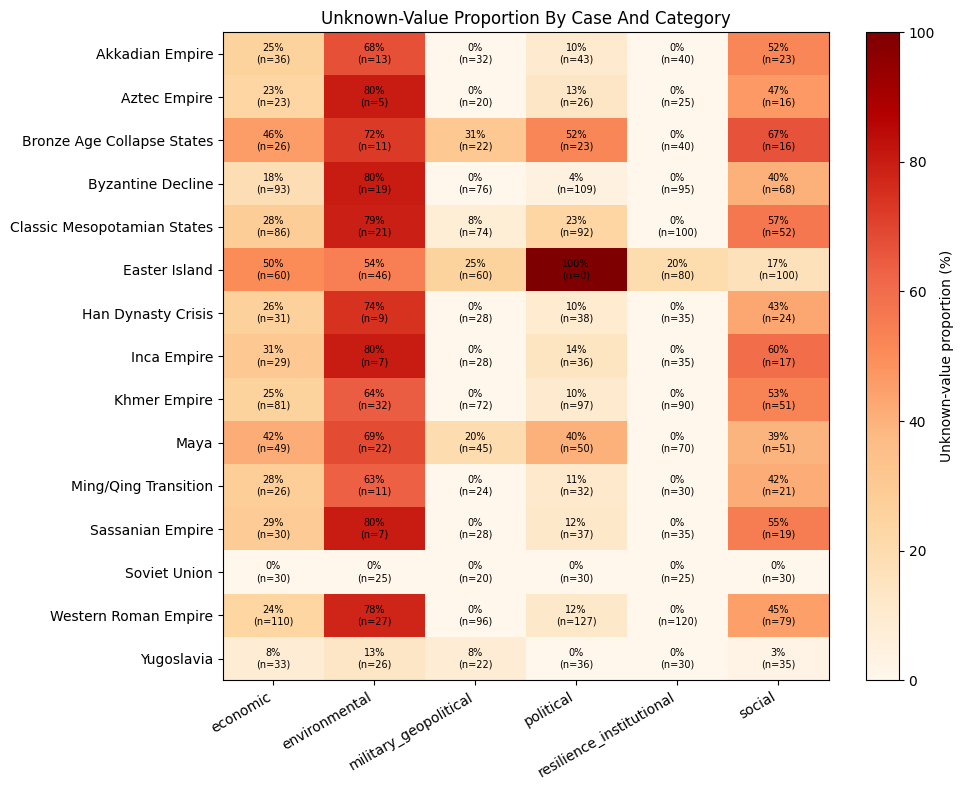

In [5]:
heatmap_data = (case_category_unknown * 100).round(1)
matrix = np.ma.masked_invalid(heatmap_data.to_numpy())
cmap = plt.cm.OrRd.copy()
cmap.set_bad(color="lightgray")

fig, ax = plt.subplots(figsize=(10, 8))
image = ax.imshow(matrix, aspect="auto", cmap=cmap, vmin=0, vmax=100)
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, rotation=30, ha="right")
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)
ax.set_title("Unknown-Value Proportion By Case And Category")

for row_idx, case_name in enumerate(heatmap_data.index):
    for col_idx, category in enumerate(heatmap_data.columns):
        value = heatmap_data.loc[case_name, category]
        count = int(case_category_known_n.loc[case_name, category])
        if pd.notna(value):
            ax.text(col_idx, row_idx, f"{value:.0f}%\n(n={count})", ha="center", va="center", fontsize=7)

colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("Unknown-value proportion (%)")
plt.tight_layout()
plt.show()

## Cases And Factors That Need Caution

These views identify where the draft coding is most limited by uncertainty and where known-score patterns remain strongest.

In [6]:
highest_uncertainty_cases = case_uncertainty.head(8)
highest_uncertainty_factors = factor_uncertainty.head(10)
strongest_known_stress_cases = case_stress.head(10)
most_evidence_limited_rows = row_evidence_limits.head(20)

display(highest_uncertainty_cases)
display(highest_uncertainty_factors)
display(strongest_known_stress_cases)
display(most_evidence_limited_rows)

,rows,known_factor_values,unknown_9_values,mean_known_factor_score,avg_collapse_outcome,data_confidence_mode,total_factor_slots,unknown_prop
case_name,,,,,,,,
Bronze Age Collapse States,8,138,118,1.487,1.750,low,256,0.461
Easter Island,20,346,294,0.991,1.100,low,640,0.459
Maya,14,287,161,1.465,1.214,medium,448,0.359
Classic Mesopotamian States,20,425,215,1.566,1.400,low,640,0.336
Inca Empire,7,152,72,1.316,0.857,medium,224,0.321
Sassanian Empire,7,156,68,1.448,1.286,medium,224,0.304
Aztec Empire,5,115,45,1.393,1.000,medium,160,0.281
Western Roman Empire,24,559,209,1.474,1.042,medium,768,0.272


,category,known_n,unknown_9_n,mean_known_score,unknown_prop
temperature_anomaly,environmental,13,161,0.231,0.925
flood_environmental_shock,environmental,16,158,0.688,0.908
inflation_currency_instability,economic,19,155,1.526,0.891
ethnic_sectarian_fragmentation,social,31,143,0.645,0.822
ecological_degradation,environmental,36,138,1.306,0.793
demographic_pressure,social,41,133,1.098,0.764
drought_climate_stress,environmental,42,132,1.286,0.759
corruption_governance_failure,political,58,116,1.983,0.667
migration_pressure,social,100,74,1.240,0.425
social_inequality,social,109,65,1.771,0.374


,mean_known_factor_score,known_factor_values,unknown_prop,avg_collapse_outcome
case_name,,,,
Han Dynasty Crisis,1.817,165,0.263,2.143
Byzantine Decline,1.802,460,0.243,1.895
Ming/Qing Transition,1.762,144,0.250,1.667
Akkadian Empire,1.590,187,0.270,1.500
Classic Mesopotamian States,1.566,425,0.336,1.400
Bronze Age Collapse States,1.487,138,0.461,1.750
Western Roman Empire,1.474,559,0.272,1.042
Maya,1.465,287,0.359,1.214
Sassanian Empire,1.448,156,0.304,1.286


,case_id,case_name,period_start,period_end,phase_label,collapse_outcome,data_confidence,notes,known_factor_count,unknown_9_count,unknown_prop,mean_known_factor_score
18,bronze_age_-1175_-1150,Bronze Age Collapse States,-1175,-1150,post-collapse,3,low,Post-collapse fragmentation remains severe eve...,12,20,0.625,1.500
19,bronze_age_-1150_-1125,Bronze Age Collapse States,-1150,-1125,post-collapse,3,low,Post-collapse fragmentation remains severe eve...,12,20,0.625,1.500
20,bronze_age_-1125_-1100,Bronze Age Collapse States,-1125,-1100,post-collapse,2,low,"The collapse horizon has passed, but regional ...",12,20,0.625,1.417
44,mesopotamian_-2000_-1975,Classic Mesopotamian States,-2000,-1975,post-collapse,2,low,"Post-Ur III fragmentation persists, but instit...",12,20,0.625,1.583
45,mesopotamian_-1975_-1950,Classic Mesopotamian States,-1975,-1950,post-collapse,2,low,"Post-Ur III fragmentation persists, but instit...",12,20,0.625,1.583
124,maya_900_925,Maya,900,925,post-collapse,2,medium,Abandonment and fragmentation remain severe ac...,12,20,0.625,1.583
125,maya_925_950,Maya,925,950,post-collapse,1,medium,Southern lowland losses remain substantial aft...,12,20,0.625,1.417
64,easter_island_1300_1325,Easter Island,1300,1325,stressed,1,low,Resource constraints and ecological change inc...,17,15,0.469,0.882
65,easter_island_1325_1350,Easter Island,1325,1350,stressed,1,low,Resource constraints and ecological change inc...,17,15,0.469,0.882
66,easter_island_1350_1375,Easter Island,1350,1375,stressed,1,low,Resource constraints and ecological change inc...,17,15,0.469,0.882


## Final Summary

The section below provides a concise reporting-oriented summary that keeps the first-pass and uncertainty-aware status of the dataset explicit.

In [7]:
top_cases = ", ".join(case_uncertainty.head(5).index.tolist())
top_factors = ", ".join(factor_uncertainty.head(5).index.tolist())
stress_cases = ", ".join(case_stress.head(5).index.tolist())
limited_rows = ", ".join(row_evidence_limits.head(5)["case_id"].tolist())

summary_md = f"""
### Reporting Notes

- This dataset is a **first-pass machine-assisted coding draft** built from secondary-literature case analyses and still requires human review and refinement.
- Uncertain, weakly supported, debated, or not-clearly-applicable values were intentionally coded as **`9`** rather than forced into false precision.
- The most uncertain cases in the current draft are **{top_cases}**, while the most uncertainty-prone factors are **{top_factors}**.
- The strongest known multi-factor stress patterns currently appear in **{stress_cases}**, but those patterns should always be interpreted together with known-value counts and uncertainty proportions.
- Rows that are especially evidence-limited and should be treated cautiously include **{limited_rows}**.
- Stronger conclusions should rely more heavily on patterns that remain visible **despite uncertainty**, especially when they recur across multiple cases and categories rather than depending on sparsely known factors.
"""

display(Markdown(summary_md))


### Reporting Notes

- This dataset is a **first-pass machine-assisted coding draft** built from secondary-literature case analyses and still requires human review and refinement.
- Uncertain, weakly supported, debated, or not-clearly-applicable values were intentionally coded as **`9`** rather than forced into false precision.
- The most uncertain cases in the current draft are **Bronze Age Collapse States, Easter Island, Maya, Classic Mesopotamian States, Inca Empire**, while the most uncertainty-prone factors are **temperature_anomaly, flood_environmental_shock, inflation_currency_instability, ethnic_sectarian_fragmentation, ecological_degradation**.
- The strongest known multi-factor stress patterns currently appear in **Han Dynasty Crisis, Byzantine Decline, Ming/Qing Transition, Akkadian Empire, Classic Mesopotamian States**, but those patterns should always be interpreted together with known-value counts and uncertainty proportions.
- Rows that are especially evidence-limited and should be treated cautiously include **bronze_age_-1175_-1150, bronze_age_-1150_-1125, bronze_age_-1125_-1100, mesopotamian_-2000_-1975, mesopotamian_-1975_-1950**.
- Stronger conclusions should rely more heavily on patterns that remain visible **despite uncertainty**, especially when they recur across multiple cases and categories rather than depending on sparsely known factors.
